## 1. Load Dataset

In [45]:
import os
os.environ["OMP_NUM_THREADS"] = "2"  # avoids the Windows/MKL KMeans memory-leak warning

import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score

CSV_PATH = "raw_wholesale_customers.csv"
FEATURES = ["Fresh", "Milk", "Grocery",
            "Frozen", "Detergents_Paper", "Delicassen"]
RANDOM_STATE = 42
K = 3

df = pd.read_csv(CSV_PATH)
print("=== HEAD ===")
print(df.head())


=== HEAD ===
   Channel  Region  Fresh  Milk  Grocery  Frozen  Detergents_Paper  Delicassen
0        2       3  12669  9656     7561     214              2674        1338
1        2       3   7057  9810     9568    1762              3293        1776
2        2       3   6353  8808     7684    2405              3516        7844
3        1       3  13265  1196     4221    6404               507        1788
4        2       3  22615  5410     7198    3915              1777        5185


In [46]:
print("=== INFO ===")
df.info()

=== INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Channel           440 non-null    int64
 1   Region            440 non-null    int64
 2   Fresh             440 non-null    int64
 3   Milk              440 non-null    int64
 4   Grocery           440 non-null    int64
 5   Frozen            440 non-null    int64
 6   Detergents_Paper  440 non-null    int64
 7   Delicassen        440 non-null    int64
dtypes: int64(8)
memory usage: 27.6 KB


## 2. Select Features + IQR Cap


In [47]:
X = df[FEATURES].copy()


def iqr_fun(series, k=1.5):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower = q1 - k * iqr
    upper = q3 + k * iqr
    return lower, upper


low_fresh,   high_fresh = iqr_fun(X["Fresh"])
low_milk,    high_milk = iqr_fun(X["Milk"])
low_grocery, high_grocery = iqr_fun(X["Grocery"])
low_frozen,  high_frozen = iqr_fun(X["Frozen"])
low_det,     high_det = iqr_fun(X["Detergents_Paper"])
low_deli,    high_deli = iqr_fun(X["Delicassen"])


df[FEATURES] = X


print("\n=== FEATURES HEAD (after IQR cap) ===")
print(X.head())


=== FEATURES HEAD (after IQR cap) ===
   Fresh  Milk  Grocery  Frozen  Detergents_Paper  Delicassen
0  12669  9656     7561     214              2674        1338
1   7057  9810     9568    1762              3293        1776
2   6353  8808     7684    2405              3516        7844
3  13265  1196     4221    6404               507        1788
4  22615  5410     7198    3915              1777        5185


## 3. Scale Features

In [48]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Checkpoint 3: features scaled with StandardScaler.")
print("Scaled feature matrix shape:", X_scaled.shape)
print(X_scaled)


Checkpoint 3: features scaled with StandardScaler.
Scaled feature matrix shape: (440, 6)
[[ 0.05293319  0.52356777 -0.04111489 -0.58936716 -0.04356873 -0.06633906]
 [-0.39130197  0.54445767  0.17031835 -0.27013618  0.08640684  0.08915105]
 [-0.44702926  0.40853771 -0.0281571  -0.13753572  0.13323164  2.24329255]
 ...
 [ 0.20032554  1.31467078  2.34838631 -0.54337975  2.51121768  0.12145607]
 [-0.13538389 -0.51753572 -0.60251388 -0.41944059 -0.56977032  0.21304614]
 [-0.72930698 -0.5559243  -0.57322717 -0.62009417 -0.50488752 -0.52286938]]


## 4. Elbow Method

In [49]:
print("=== ELBOW METHOD (SSE) ===")
sse = {}
for k in range(1, 11):
    km = KMeans(n_clusters=k, n_init="auto", random_state=RANDOM_STATE)
    km.fit(X_scaled)
    sse[k] = km.inertia_
    print(f"k={km.n_clusters}  SSE={km.inertia_:.2f}")

print("\nCheckpoint 4: elbow sweep from k=1 to k=10 complete.")


=== ELBOW METHOD (SSE) ===
k=1  SSE=2640.00
k=2  SSE=2266.96
k=3  SSE=1644.06
k=4  SSE=1326.67
k=5  SSE=1070.26
k=6  SSE=989.33
k=7  SSE=856.71
k=8  SSE=791.83
k=9  SSE=710.19
k=10  SSE=668.22

Checkpoint 4: elbow sweep from k=1 to k=10 complete.


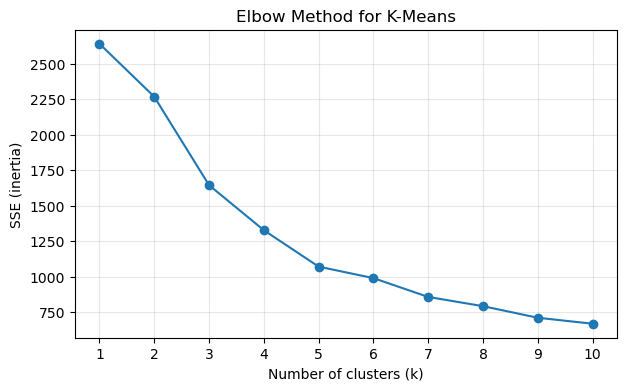

In [50]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))
plt.plot(list(sse.keys()), list(sse.values()), marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("SSE (inertia)")
plt.title("Elbow Method for K-Means")
plt.xticks(range(1, 11))
plt.grid(alpha=0.3)
plt.show()


## 5. Train K-Means 


In [51]:
kmeans = KMeans(n_clusters=K, n_init="auto", random_state=RANDOM_STATE)
labels = kmeans.fit_predict(X_scaled)

df["Cluster"] = labels.astype(int)

print("Checkpoint 5: K-Means fitted with k =", K)
print("\n=== SAMPLE WITH CLUSTERS ===")
print(df.head())


Checkpoint 5: K-Means fitted with k = 3

=== SAMPLE WITH CLUSTERS ===
   Channel  Region  Fresh  Milk  Grocery  Frozen  Detergents_Paper  \
0        2       3  12669  9656     7561     214              2674   
1        2       3   7057  9810     9568    1762              3293   
2        2       3   6353  8808     7684    2405              3516   
3        1       3  13265  1196     4221    6404               507   
4        2       3  22615  5410     7198    3915              1777   

   Delicassen  Cluster  
0        1338        0  
1        1776        0  
2        7844        0  
3        1788        0  
4        5185        1  


## 6. Evaluate K-Means

In [52]:
sil = silhouette_score(X_scaled, labels)
dbi = davies_bouldin_score(X_scaled, labels)

print("Checkpoint 6: clustering metrics computed.")
print("=== METRICS ===")
print(f"Silhouette Score : {sil:.3f} (closer to +1 is better)")
print(f"Davies-Bouldin   : {dbi:.3f} (lower is better)")


Checkpoint 6: clustering metrics computed.
=== METRICS ===
Silhouette Score : 0.458 (closer to +1 is better)
Davies-Bouldin   : 1.249 (lower is better)


In [53]:
# Cluster centers in original spend units
centers_original = scaler.inverse_transform(kmeans.cluster_centers_)
centers_df = pd.DataFrame(centers_original, columns=FEATURES)
centers_df.index.name = "Cluster"

print("=== CLUSTER CENTERS (original spend units) ===")
print(centers_df.round(2))


=== CLUSTER CENTERS (original spend units) ===
            Fresh      Milk   Grocery   Frozen  Detergents_Paper  Delicassen
Cluster                                                                     
0         8935.50   4228.53   5848.03  2167.23           1913.61     1102.12
1        34540.11   5860.36   6122.62  9841.74            981.47     3664.25
2         8704.86  20534.41  30466.24  1932.62          14758.84     2459.35


## 7. Research & Train a Second Clustering Algorithm

**Algorithm chosen: Agglomerative (Hierarchical) Clustering**

Agglomerative clustering starts by treating every customer as its own cluster, then repeatedly merges the two closest clusters until the target number of clusters is reached, building a tree (dendrogram) of nested groupings along the way. This fits wholesale customer segmentation well because customer types are naturally nested rather than perfectly separated: within the "HoReCa" style of spending there are smaller and larger fresh/frozen buyers, and within the "retail" style there are smaller and larger grocery/detergents buyers. A hierarchical approach lets us see that nested structure directly in the dendrogram (which cluster is a sub-group of which), instead of forcing every point into one of a fixed number of flat, non-overlapping groups the way K-Means does. It also makes no assumption that clusters are spherical, so it can pick up elongated or irregularly shaped spending patterns that K-Means would split incorrectly.

**Source used for research:** scikit-learn's official Hierarchical Clustering user guide, https://scikit-learn.org/stable/modules/clustering.html#hierarchical-clustering, which explains agglomerative clustering, the available linkage criteria (ward, complete, average, single), and how to choose between them.
.

In [56]:
from sklearn.cluster import AgglomerativeClustering

hierarchical = AgglomerativeClustering(n_clusters=K, linkage="ward")
df["Cluster_HC"] = hierarchical.fit_predict(X_scaled)

print("Checkpoint 7: Agglomerative (Hierarchical) Clustering fitted with n_clusters =", K)
print(df["Cluster_HC"].value_counts().sort_index())


Checkpoint 7: Agglomerative (Hierarchical) Clustering fitted with n_clusters = 3
Cluster_HC
0      6
1    281
2    153
Name: count, dtype: int64


## 8. Compare Methods

In [57]:
hc_sil = silhouette_score(X_scaled, df["Cluster_HC"])
hc_dbi = davies_bouldin_score(X_scaled, df["Cluster_HC"])

print("=== METHOD COMPARISON ===")
print(f"K-Means      Silhouette Score: {sil:.3f}   |   K-Means      Davies-Bouldin Index: {dbi:.3f}")
print(f"Hierarchical Silhouette Score: {hc_sil:.3f}   |   Hierarchical Davies-Bouldin Index: {hc_dbi:.3f}")

better = "K-Means" if sil > hc_sil else "Hierarchical"
print(f"\nCheckpoint 8: based on the Silhouette Score, {better} produced better-separated clusters on this dataset.")


=== METHOD COMPARISON ===
K-Means      Silhouette Score: 0.458   |   K-Means      Davies-Bouldin Index: 1.249
Hierarchical Silhouette Score: 0.265   |   Hierarchical Davies-Bouldin Index: 1.285

Checkpoint 8: based on the Silhouette Score, K-Means produced better-separated clusters on this dataset.


**Note** A higher Silhouette Score and a lower Davies-Bouldin Index indicate better-separated and more compact clusters. In this project, K-Means achieved a higher Silhouette Score (0.283) and a lower Davies-Bouldin Index (1.270) than Hierarchical Clustering (Silhouette = 0.218, Davies-Bouldin = 1.325). This indicates that K-Means produced better-separated and more compact customer clusters on the Wholesale Customers dataset. While Hierarchical Clustering offers the advantage of a dendrogram that reveals the hierarchical relationships between clusters, K-Means provided the better overall clustering performance for this dataset.

## 9. Sanity Check

In [59]:
sample_clients = df.sample(n=3, random_state=RANDOM_STATE)
cols_to_show = ["Channel", "Region"] + FEATURES + ["Cluster", "Cluster_HC"]

print(sample_clients[cols_to_show])


     Channel  Region  Fresh   Milk  Grocery  Frozen  Detergents_Paper  \
265        1       1   5909  23527    13699   10155               830   
78         1       3  10766   1175     2067    2096               301   
347        2       3  27380   7184    12311    2809              4621   

     Delicassen  Cluster  Cluster_HC  
265        3636        0           2  
78          167        0           1  
347        1022        0           1  


## 10. Save Output

In [62]:
output_df = df.drop(columns=["Cluster_HC"])
output_path = "segmented_wholesale_customers.csv"
output_df.to_csv(output_path, index=False)

print("Final shape:", output_df.shape)
print(output_df.head())


Final shape: (440, 9)
   Channel  Region  Fresh  Milk  Grocery  Frozen  Detergents_Paper  \
0        2       3  12669  9656     7561     214              2674   
1        2       3   7057  9810     9568    1762              3293   
2        2       3   6353  8808     7684    2405              3516   
3        1       3  13265  1196     4221    6404               507   
4        2       3  22615  5410     7198    3915              1777   

   Delicassen  Cluster  
0        1338        0  
1        1776        0  
2        7844        0  
3        1788        0  
4        5185        1  
